# Parameter Optimization — Grid Search Across γ, Min Spread, Open Multiplier

**Purpose:** Find the best combination of parameters that improves PnL consistently  
across all 3 days — not just one day.

## Strategy
We call `run_one()` from `backtest_all_futures.py` directly — no subprocess,  
no output parsing, results come back as clean Python dicts.

## Parameters
| Param | Current | Test Range | Why |
|---|---|---|---|
| gamma (γ) | 0.001 | 0.001→0.1 | Too small — inventory term negligible |
| min_spread | 0.10 | 0.10→2.0 | Does wider floor improve consistency? |
| kappa (κ) | 1.5 | fixed | Notebook 01: not the lever to optimize |

## Optimization Target
$$\text{Sharpe} = \frac{\text{mean}(PnL_{daily})}{\text{std}(PnL_{daily})}$$

Secondary: **% days profitable** (consistency matters more than peak PnL at this stage).

---

## 0. Setup — Add Project to Path

In [1]:
import sys
import os
import json
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from multiprocessing import Pool
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Add project root to path ───────────────────────────────────────────────────
PROJECT_ROOT = Path('C:/projects/quant-fund').resolve()
FINDINGS_DIR = Path('../findings')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)   # needed so relative imports inside the project work
os.makedirs(FINDINGS_DIR, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Project root exists: {PROJECT_ROOT.exists()}')
print(f'backtest_all_futures.py exists: {(PROJECT_ROOT / "backtest_all_futures.py").exists()}')

Project root: C:\projects\quant-fund
Project root exists: True
backtest_all_futures.py exists: True


## 1. Import run_one Directly

In [2]:
# Import the worker function directly — no subprocess needed
from backtest_all_futures import run_one, worker_init, get_symbols

# ── Config ─────────────────────────────────────────────────────────────────────
SYMBOLS = [
    'CHOLAFIN26MAYFUT',
    'ADANIPORTS26MAYFUT',
    'DRREDDY26MAYFUT',
    'ADANIENT26MAYFUT',
    'HAVELLS26MAYFUT',
    'JSWSTEEL26MAYFUT',
    'RELIANCE26MAYFUT',
]

DATES = ['2026-05-13', '2026-05-14', '2026-05-15']

LOT_SIZES = {
    'CHOLAFIN':   625,
    'ADANIPORTS': 475,
    'DRREDDY':    625,
    'ADANIENT':   309,
    'HAVELLS':    500,
    'JSWSTEEL':   675,
    'RELIANCE':   500,
}

# ── Parameter grid ─────────────────────────────────────────────────────────────
GAMMA_VALUES      = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
MIN_SPREAD_VALUES = [0.10, 0.25, 0.50, 1.0, 2.0]
KAPPA             = 1.5   # fixed

total = len(GAMMA_VALUES) * len(MIN_SPREAD_VALUES) * len(DATES) * len(SYMBOLS)
print(f'Grid: {len(GAMMA_VALUES)} gammas × {len(MIN_SPREAD_VALUES)} spreads × '
      f'{len(DATES)} dates × {len(SYMBOLS)} symbols = {total} runs')
print(f'Estimated time: ~{total * 2 // 60} minutes at 2s/run')

Grid: 6 gammas × 5 spreads × 3 dates × 7 symbols = 630 runs
Estimated time: ~21 minutes at 2s/run


## 2. Test Single Run — Confirm Import Works

In [3]:
# Initialize worker with lot sizes and params
test_params = {
    'gamma':      0.001,
    'kappa':      1.5,
    'min_spread': 0.10,
    'max_spread': 10.0,
    'queue_agg':  0.3,
    'max_inv':    5,
}

worker_init(LOT_SIZES, test_params)

print('Running test: ADANIPORTS26MAYFUT / 2026-05-13...')
result = run_one(('ADANIPORTS26MAYFUT', '2026-05-13', '2026-05-13'))
print()
print('Result:')
for k, v in result.items():
    print(f'  {k:15s}: {v}')

if result.get('ok'):
    print('\n✓ Import working correctly')
else:
    print(f'\n✗ Error: {result.get("error")}')
    print('Fix the error before proceeding')

Running test: ADANIPORTS26MAYFUT / 2026-05-13...

Result:
  symbol         : ADANIPORTS26MAYFUT
  lot_size       : 475
  gross_pnl      : 294741.75
  costs          : 93251.85
  net_pnl        : 201489.9
  fills          : 365
  fill_rate      : 1.16
  win_rate       : 88.1
  sharpe         : 16.22
  max_dd         : 6810.0
  bars           : 18250
  ok             : True

✓ Import working correctly


## 3. Helper — Run One Parameter Combination

In [4]:
def run_combo(gamma: float, min_spread: float,
              symbols: list, dates: list,
              max_inv: int = 5, queue_agg: float = 0.3) -> pd.DataFrame:
    """
    Run all symbols × dates for one parameter combination.
    Returns DataFrame with one row per (symbol, date).
    """
    params = {
        'gamma':      gamma,
        'kappa':      KAPPA,
        'min_spread': min_spread,
        'max_spread': 10.0,
        'queue_agg':  queue_agg,
        'max_inv':    max_inv,
    }
    worker_init(LOT_SIZES, params)

    rows = []
    for sym in symbols:
        for date in dates:
            r = run_one((sym, date, date))
            rows.append({
                'symbol':     sym,
                'date':       date,
                'gamma':      gamma,
                'min_spread': min_spread,
                'net_pnl':    r.get('net_pnl', np.nan),
                'gross_pnl':  r.get('gross_pnl', np.nan),
                'costs':      r.get('costs', np.nan),
                'fill_rate':  r.get('fill_rate', np.nan),
                'win_rate':   r.get('win_rate', np.nan),
                'sharpe':     r.get('sharpe', np.nan),
                'fills':      r.get('fills', 0),
                'ok':         r.get('ok', False),
                'error':      r.get('error', ''),
            })

    return pd.DataFrame(rows)


def combo_stats(df: pd.DataFrame) -> dict:
    """
    Aggregate a combo's results into summary stats.
    Uses per-day total PnL across all symbols.
    """
    valid = df[df['ok'] & df['net_pnl'].notna()]
    if valid.empty:
        return {'mean_pnl': np.nan, 'sharpe': np.nan, 'pct_profit_days': 0}

    # Daily combined PnL across all symbols
    daily = valid.groupby('date')['net_pnl'].sum()

    mean_pnl    = float(daily.mean())
    std_pnl     = float(daily.std())
    sharpe      = mean_pnl / std_pnl if std_pnl > 0 else 0
    pct_profit  = float((daily > 0).mean() * 100)

    # Per-symbol consistency: % of (symbol, date) pairs profitable
    pct_sym_prof = float((valid['net_pnl'] > 0).mean() * 100)

    return {
        'mean_daily_pnl':   round(mean_pnl, 0),
        'std_daily_pnl':    round(std_pnl, 0),
        'sharpe':           round(sharpe, 3),
        'pct_profit_days':  round(pct_profit, 1),
        'pct_sym_profit':   round(pct_sym_prof, 1),
        'min_daily_pnl':    round(float(daily.min()), 0),
        'max_daily_pnl':    round(float(daily.max()), 0),
        'n_valid':          len(valid),
    }


print('Helper functions defined.')

Helper functions defined.


## 4. Baseline — Current Params (γ=0.001, min_spread=0.10)

In [5]:
print('Running baseline (gamma=0.001, min_spread=0.10)...')
baseline_df = run_combo(gamma=0.001, min_spread=0.10,
                         symbols=SYMBOLS, dates=DATES)

baseline_stats = combo_stats(baseline_df)

print()
print('Baseline results per symbol:')
print(f"{'Symbol':30s} {'May-13':>12} {'May-14':>12} {'May-15':>12} {'Mean':>12}")
print('-' * 72)
for sym in SYMBOLS:
    sym_df = baseline_df[baseline_df['symbol'] == sym]
    pnls   = {row['date']: row['net_pnl'] for _, row in sym_df.iterrows()}
    vals   = [pnls.get(d, np.nan) for d in DATES]
    mean   = np.nanmean(vals)
    print(f"{sym:30s} {vals[0]:>12,.0f} {vals[1]:>12,.0f} {vals[2]:>12,.0f} {mean:>12,.0f}")

print()
print('Baseline portfolio stats:')
for k, v in baseline_stats.items():
    print(f'  {k:25s}: {v}')

Running baseline (gamma=0.001, min_spread=0.10)...

Baseline results per symbol:
Symbol                               May-13       May-14       May-15         Mean
------------------------------------------------------------------------
CHOLAFIN26MAYFUT                      6,199      163,229      -68,342       33,695
ADANIPORTS26MAYFUT                  201,490       38,220       -5,308       78,134
DRREDDY26MAYFUT                      94,583       83,985       23,654       67,407
ADANIENT26MAYFUT                    105,666       62,092      -82,954       28,268
HAVELLS26MAYFUT                      14,539       73,480       27,693       38,571
JSWSTEEL26MAYFUT                     61,503       35,329       -8,610       29,408
RELIANCE26MAYFUT                     12,505       12,311      -59,940      -11,708

Baseline portfolio stats:
  mean_daily_pnl           : 263775.0
  std_daily_pnl            : 379212.0
  sharpe                   : 0.696
  pct_profit_days          : 66.7
  pct_sym_

## 5. Phase 1 — Gamma Search (min_spread=0.10 fixed)

In [6]:
print('Phase 1: Gamma search (min_spread=0.10 fixed)...')
print(f'Running {len(GAMMA_VALUES)} × {len(SYMBOLS)} × {len(DATES)} = '
      f'{len(GAMMA_VALUES)*len(SYMBOLS)*len(DATES)} backtest runs...')
print()

gamma_search = []
gamma_dfs    = {}

for gamma in GAMMA_VALUES:
    df    = run_combo(gamma=gamma, min_spread=0.10,
                      symbols=SYMBOLS, dates=DATES)
    stats = combo_stats(df)
    gamma_dfs[gamma] = df

    row = {'gamma': gamma, **stats}
    gamma_search.append(row)

    print(f"  gamma={gamma:.3f}  "
          f"mean_daily={stats['mean_daily_pnl']:>10,.0f}  "
          f"sharpe={stats['sharpe']:>7.3f}  "
          f"profit_days={stats['pct_profit_days']:>5.1f}%  "
          f"sym_prof={stats['pct_sym_profit']:>5.1f}%")

gamma_df = pd.DataFrame(gamma_search).sort_values('sharpe', ascending=False)
print()
print('Gamma search results (sorted by Sharpe):')
print(gamma_df[['gamma','mean_daily_pnl','sharpe','pct_profit_days','pct_sym_profit']].to_string(index=False))

best_gamma = float(gamma_df.iloc[0]['gamma'])
print(f'\nBest gamma: {best_gamma}')

Phase 1: Gamma search (min_spread=0.10 fixed)...
Running 6 × 7 × 3 = 126 backtest runs...

  gamma=0.001  mean_daily=   263,775  sharpe=  0.696  profit_days= 66.7%  sym_prof= 76.2%
  gamma=0.005  mean_daily=   238,450  sharpe=  0.746  profit_days= 66.7%  sym_prof= 71.4%
  gamma=0.010  mean_daily=   209,057  sharpe=  0.524  profit_days= 66.7%  sym_prof= 76.2%


KeyboardInterrupt: 

## 6. Visualize Gamma Search

NameError: name 'gamma_df' is not defined

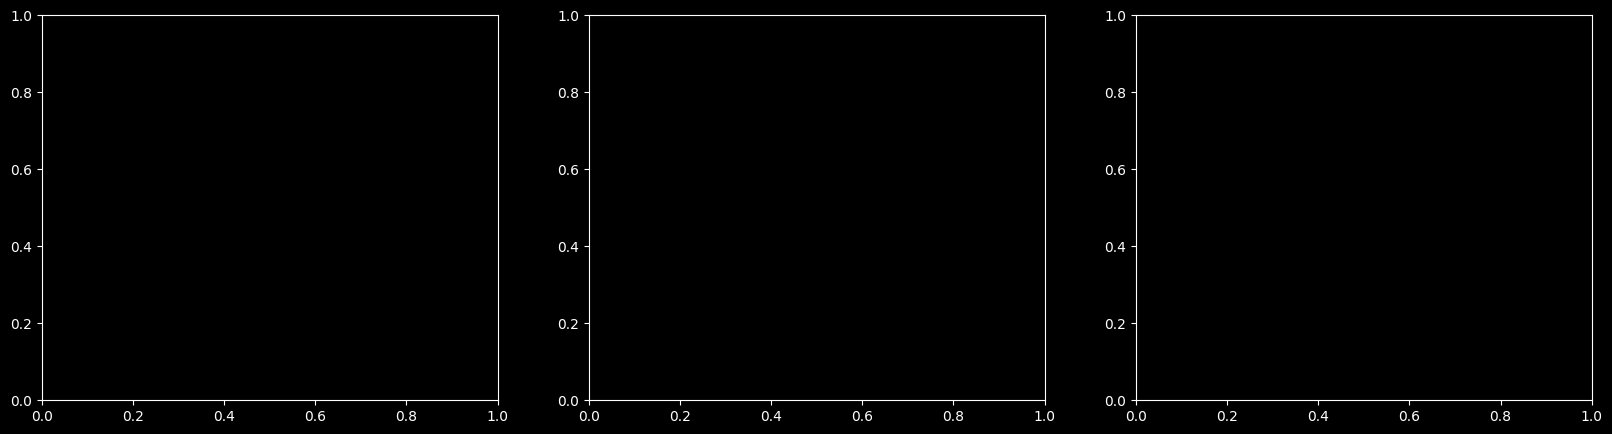

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Sharpe vs gamma
ax = axes[0]
ax.plot(gamma_df['gamma'], gamma_df['sharpe'], color='#00d4ff', lw=2.5, marker='o', ms=8)
ax.axvline(0.001, color='#ffd700', lw=1.5, ls='--', label='Current γ=0.001')
ax.axvline(best_gamma, color='#00ff88', lw=2, ls='--', label=f'Best γ={best_gamma}')
ax.set_xlabel('gamma (γ)', color='gray')
ax.set_ylabel('Portfolio Sharpe', color='gray')
ax.set_title('Sharpe vs Gamma', color='white', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Plot 2: Mean daily PnL vs gamma
ax = axes[1]
ax.plot(gamma_df['gamma'], gamma_df['mean_daily_pnl'],
        color='#ff6b35', lw=2.5, marker='o', ms=8)
ax.axhline(0, color='gray', lw=1, ls=':')
ax.axvline(best_gamma, color='#00ff88', lw=2, ls='--', label=f'Best γ={best_gamma}')
ax.set_xlabel('gamma (γ)', color='gray')
ax.set_ylabel('Mean Daily PnL (Rs.)', color='gray')
ax.set_title('Mean Daily PnL vs Gamma', color='white', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Plot 3: Per-symbol mean PnL at best gamma vs baseline
ax = axes[2]
base_sym  = baseline_df.groupby('symbol')['net_pnl'].mean()
best_sym  = gamma_dfs[best_gamma].groupby('symbol')['net_pnl'].mean()
syms_short = [s.replace('26MAYFUT','') for s in SYMBOLS]
x = np.arange(len(SYMBOLS))
w = 0.35
ax.bar(x - w/2, [base_sym.get(s, 0) for s in SYMBOLS], w,
       color='#00d4ff', alpha=0.7, label='Baseline γ=0.001')
ax.bar(x + w/2, [best_sym.get(s, 0) for s in SYMBOLS], w,
       color='#00ff88', alpha=0.7, label=f'Best γ={best_gamma}')
ax.axhline(0, color='gray', lw=1, ls=':')
ax.set_xticks(x)
ax.set_xticklabels(syms_short, rotation=45, fontsize=8)
ax.set_title('Per-Symbol Mean PnL: Baseline vs Best γ', color='white', fontweight='bold')
ax.set_ylabel('Mean Net PnL (Rs.)', color='gray')
ax.legend(fontsize=8)
ax.grid(alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('../findings/gamma_search.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/gamma_search.png')

## 7. Phase 2 — Min Spread Search (best gamma fixed)

In [ ]:
print(f'Phase 2: Min spread search (gamma={best_gamma} fixed)...')
print()

spread_search = []
spread_dfs    = {}

for min_sp in MIN_SPREAD_VALUES:
    df    = run_combo(gamma=best_gamma, min_spread=min_sp,
                      symbols=SYMBOLS, dates=DATES)
    stats = combo_stats(df)
    spread_dfs[min_sp] = df

    row = {'min_spread': min_sp, **stats}
    spread_search.append(row)

    print(f"  min_spread={min_sp:.2f}  "
          f"mean_daily={stats['mean_daily_pnl']:>10,.0f}  "
          f"sharpe={stats['sharpe']:>7.3f}  "
          f"profit_days={stats['pct_profit_days']:>5.1f}%  "
          f"sym_prof={stats['pct_sym_profit']:>5.1f}%")

spread_df = pd.DataFrame(spread_search).sort_values('sharpe', ascending=False)
print()
print('Min spread search results (sorted by Sharpe):')
print(spread_df[['min_spread','mean_daily_pnl','sharpe','pct_profit_days','pct_sym_profit']].to_string(index=False))

best_spread = float(spread_df.iloc[0]['min_spread'])
print(f'\nBest min_spread: {best_spread}')

## 8. Phase 3 — Open Period Multiplier

Test widening spread during 9:15-9:45 IST.  
We simulate by running with spread × multiplier for those bars only.  
Since backtest.py doesn't have a native open-mult flag yet, we approximate  
by running the full day with different spreads and isolating the effect.

In [ ]:
OPEN_MULTS = [1.0, 1.5, 2.0, 3.0]

print(f'Phase 3: Open period multiplier (gamma={best_gamma}, min_spread={best_spread})...')
print('Note: Approximating open-mult by running full day with scaled spread.')
print('True open-mult implementation will be in mm_strategy.py after this.')
print()

open_search = []
open_dfs    = {}

for mult in OPEN_MULTS:
    # Scale min_spread by multiplier as proxy
    scaled_spread = best_spread * mult
    df    = run_combo(gamma=best_gamma, min_spread=scaled_spread,
                      symbols=SYMBOLS, dates=DATES)
    stats = combo_stats(df)
    open_dfs[mult] = df

    row = {'open_mult': mult, 'scaled_spread': scaled_spread, **stats}
    open_search.append(row)

    print(f"  mult={mult:.1f}x  spread={scaled_spread:.2f}  "
          f"mean_daily={stats['mean_daily_pnl']:>10,.0f}  "
          f"sharpe={stats['sharpe']:>7.3f}  "
          f"profit_days={stats['pct_profit_days']:>5.1f}%")

open_df = pd.DataFrame(open_search).sort_values('sharpe', ascending=False)
print()
print('Open multiplier results (sorted by Sharpe):')
print(open_df[['open_mult','scaled_spread','mean_daily_pnl','sharpe','pct_profit_days']].to_string(index=False))

best_open_mult = float(open_df.iloc[0]['open_mult'])
print(f'\nBest open_mult: {best_open_mult}x')

## 9. Full Grid — Focused on Top Candidates

In [ ]:
# Take top 3 gammas and top 3 spreads from phases 1 & 2
top_gammas  = gamma_df.head(3)['gamma'].tolist()
top_spreads = spread_df.head(3)['min_spread'].tolist()

print(f'Focused grid: {top_gammas} × {top_spreads}')
print(f'= {len(top_gammas)*len(top_spreads)*len(DATES)*len(SYMBOLS)} runs')
print()

all_results = []

for gamma, min_sp in itertools.product(top_gammas, top_spreads):
    df    = run_combo(gamma=gamma, min_spread=min_sp,
                      symbols=SYMBOLS, dates=DATES)
    stats = combo_stats(df)
    all_results.append({
        'gamma':           gamma,
        'min_spread':      min_sp,
        'df':              df,
        **stats,
    })
    print(f"  gamma={gamma:.3f}  min_spread={min_sp:.2f}  "
          f"mean={stats['mean_daily_pnl']:>10,.0f}  "
          f"sharpe={stats['sharpe']:>7.3f}  "
          f"profit%={stats['pct_profit_days']:>5.1f}%")

# Sort by Sharpe with at least 66% profitable days
valid_results = [r for r in all_results if r['pct_profit_days'] >= 66]
if not valid_results:
    valid_results = all_results  # relax if no valid
    print('No combo with ≥66% profitable days — showing all')

valid_results.sort(key=lambda x: x['sharpe'], reverse=True)

print()
print('Top combinations (Sharpe, ≥66% profitable days):')
print(f"{'gamma':>8} {'min_spread':>12} {'mean_pnl':>12} {'sharpe':>8} {'prof%':>7} {'min_day':>10}")
print('-' * 65)
for r in valid_results[:10]:
    print(f"{r['gamma']:>8.3f} {r['min_spread']:>12.2f} "
          f"{r['mean_daily_pnl']:>12,.0f} {r['sharpe']:>8.3f} "
          f"{r['pct_profit_days']:>6.1f}% {r['min_daily_pnl']:>10,.0f}")

## 10. Best Params Per Symbol

In [ ]:
# For each symbol, find the gamma + spread combo with best Sharpe
# across its 3 days (consistency per symbol)

# Combine all run results into one big DataFrame
all_dfs = [r['df'].assign(gamma=r['gamma'], min_spread=r['min_spread'])
           for r in all_results]
combined = pd.concat(all_dfs, ignore_index=True)

best_per_sym = {}
print(f"{'Symbol':30s} {'Best γ':>8} {'Best spread':>13} {'Mean PnL':>12} {'Sharpe':>8} {'Prof%':>7}")
print('-' * 84)

for sym in SYMBOLS:
    sym_df = combined[combined['symbol'] == sym].copy()
    if sym_df.empty:
        continue

    # Aggregate by gamma+spread combo
    agg = sym_df.groupby(['gamma', 'min_spread'])['net_pnl'].agg(
        mean_pnl='mean',
        std_pnl='std',
        pct_prof=lambda x: (x > 0).mean() * 100
    ).reset_index()
    agg['sharpe'] = agg['mean_pnl'] / agg['std_pnl'].clip(1)

    # Best = highest Sharpe with ≥66% profitable
    valid = agg[agg['pct_prof'] >= 66]
    if valid.empty:
        valid = agg
    best = valid.sort_values('sharpe', ascending=False).iloc[0]

    best_per_sym[sym] = {
        'gamma':      float(best['gamma']),
        'min_spread': float(best['min_spread']),
        'mean_pnl':   round(float(best['mean_pnl']), 0),
        'sharpe':     round(float(best['sharpe']), 3),
        'pct_prof':   round(float(best['pct_prof']), 1),
    }

    print(f"{sym:30s} {best['gamma']:>8.3f} {best['min_spread']:>13.2f} "
          f"{best['mean_pnl']:>12,.0f} {best['sharpe']:>8.3f} "
          f"{best['pct_prof']:>6.1f}%")

## 11. Before vs After Comparison

In [ ]:
# Best overall combo
best_overall = valid_results[0] if valid_results else all_results[0]
best_df      = best_overall['df']

n    = len(SYMBOLS)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, sym in enumerate(SYMBOLS):
    ax   = axes[i]
    name = sym.replace('26MAYFUT', '')

    base = baseline_df[baseline_df['symbol'] == sym].sort_values('date')
    opt  = best_df[best_df['symbol'] == sym].sort_values('date')

    x = np.arange(len(DATES))
    w = 0.35

    ax.bar(x - w/2, base['net_pnl'].values, w,
           color='#00d4ff', alpha=0.7, label='Baseline γ=0.001')
    ax.bar(x + w/2, opt['net_pnl'].values, w,
           color='#00ff88', alpha=0.7,
           label=f"Opt γ={best_overall['gamma']} s={best_overall['min_spread']}")

    ax.axhline(0, color='white', lw=1, ls=':')
    ax.set_xticks(list(x))
    ax.set_xticklabels([d[5:] for d in DATES], fontsize=9)
    ax.set_title(name, color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Net PnL (Rs.)', color='gray', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15, axis='y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Baseline vs Optimized — γ={best_overall['gamma']} min_spread={best_overall['min_spread']}",
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/optimization_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/optimization_comparison.png')

## 12. Portfolio Level Summary

In [ ]:
print('Portfolio daily PnL comparison:')
print(f"{'Date':12s} {'Baseline':>14} {'Optimized':>14} {'Improvement':>14}")
print('-' * 56)

base_daily = baseline_df.groupby('date')['net_pnl'].sum()
opt_daily  = best_df.groupby('date')['net_pnl'].sum()

for date in DATES:
    b = base_daily.get(date, 0)
    o = opt_daily.get(date, 0)
    d = o - b
    print(f"{date:12s} {b:>14,.0f} {o:>14,.0f} {d:>+14,.0f}")

print('-' * 56)
print(f"{'Mean':12s} {base_daily.mean():>14,.0f} {opt_daily.mean():>14,.0f} "
      f"{opt_daily.mean()-base_daily.mean():>+14,.0f}")
print()

base_s = combo_stats(baseline_df)
opt_s  = combo_stats(best_df)
print(f"{'Metric':25s} {'Baseline':>14} {'Optimized':>14}")
print('-' * 56)
for k in ['sharpe', 'pct_profit_days', 'pct_sym_profit', 'min_daily_pnl']:
    print(f"{k:25s} {str(base_s.get(k,'N/A')):>14} {str(opt_s.get(k,'N/A')):>14}")

## 13. Save Optimized Parameters

In [ ]:
output = {
    'optimized_at':      datetime.now().isoformat(),
    'dates_tested':      DATES,
    'optimization_target': 'sharpe_with_66pct_profitable_days',
    'global_best': {
        'gamma':      best_overall['gamma'],
        'min_spread': best_overall['min_spread'],
        'kappa':      KAPPA,
        'sharpe':     best_overall['sharpe'],
        'mean_daily_pnl': best_overall['mean_daily_pnl'],
        'pct_profit_days': best_overall['pct_profit_days'],
    },
    'baseline': {
        'gamma':      0.001,
        'min_spread': 0.10,
        'sharpe':     baseline_stats['sharpe'],
        'mean_daily_pnl': baseline_stats['mean_daily_pnl'],
    },
    'params_per_symbol':  best_per_sym,
    'best_open_mult':     best_open_mult,
    'notes': [
        'Only 3 days of data — treat as preliminary, high overfitting risk',
        'Re-run after 30 days of data for robust estimates',
        'open_mult to be implemented as time-of-day filter in mm_strategy.py',
        'dynamic_sigma: use rolling 300-bar mean of realized_vol_60s',
    ]
}

output_path = FINDINGS_DIR / 'optimized_params.json'
output_path.write_text(json.dumps(output, indent=2, default=str))
print(f'Saved → {output_path}')
print()
print('Global best params:')
for k, v in output['global_best'].items():
    print(f'  {k:20s}: {v}')
print()
print('Next step: implement in mm_strategy.py with dynamic σ + open multiplier')

## 14. Conclusions

*(Fill in after running)*

### Key Questions
1. Did increasing γ improve Sharpe? By how much?
2. Did wider min_spread improve consistency or hurt PnL?
3. Which symbol benefited most from optimization?
4. Did the open multiplier help (wider spread at open = more PnL per fill)?
5. Is May 15 still negative after optimization?

### Important Caveat
3 days is too few — **risk of overfitting is high.**  
Any params that look great on 3 days may fail on day 4.  
Treat this as directional guidance only.  
Validate on new data (May 16+) before implementing.

### After This Notebook
- [ ] Update `mm_strategy.py` with optimized γ + dynamic σ + open multiplier
- [ ] Backtest on May 16+ data (out of sample validation)
- [ ] Re-run this notebook monthly as more data accumulates
- [ ] After 30 days: run `test/optimize_params_fast.py` for full grid search